In [1]:
import optuna
import joblib
import numpy as np
import pandas as pd
import lightgbm as lightgbm
import optuna.integration.lightgbm as optuna_lgb

from collections import OrderedDict
from sklearn.model_selection import ParameterGrid,train_test_split
from matplotlib import pyplot as plt


# load data

In [2]:
# load training dataset
train_path = "data/basic_dataset.csv"
chunk = pd.read_csv(train_path, chunksize=1000000)
df = pd.concat(chunk)

# data preparation

In [3]:
# split data based on search ids
train_groups, val_groups = train_test_split(df[['srch_id']].drop_duplicates(), test_size=0.1, random_state=42)

# split the actual data on those groups
train_data = df[df['srch_id'].isin(train_groups['srch_id'])]
val_data = df[df['srch_id'].isin(val_groups['srch_id'])]

# prepare X and y for train/val set
X_train = train_data.drop(columns=['click_bool', 'booking_bool', 'relevance', 'position', 'gross_bookings_usd'])
y_train = train_data['relevance']

X_val = val_data.drop(columns=['click_bool', 'booking_bool', 'relevance', 'position', 'gross_bookings_usd'])
y_val = val_data['relevance']

In [4]:
# create groups
train_group = train_data.groupby('srch_id')['srch_id'].count().to_numpy()
val_group = val_data.groupby('srch_id')['srch_id'].count().to_numpy()


# train model

In [12]:
ranker = lightgbm.LGBMRanker(
                    objective="lambdarank",
                    boosting_type = "gbdt",
                    n_estimators = 500,
                    importance_type = "gain",
                    metric= "ndcg",
                    num_leaves = 10,
                    learning_rate = 0.05,
                    max_depth = -1,
                    label_gain =[i for i in range(max(y_train.max(), y_val.max()) + 1)])

# Training the model
ranker.fit(
      X=X_train,
      y=y_train,
      group=train_group,
      eval_set=[(X_train, y_train),(X_val, y_val)],
      eval_group=[train_group, val_group],
      eval_at=[4, 8])

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.332469 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2446
[LightGBM] [Info] Number of data points in the train set: 4463261, number of used features: 21


LGBMRanker(importance_type='gain', label_gain=[0, 1, 2, 3, 4, 5],
           learning_rate=0.05, metric='ndcg', n_estimators=500, num_leaves=10,
           objective='lambdarank')

C:\Users\Dany\anaconda3\envs\ml24\lib\site-packages\lightgbm\plotting.py:381: UserWarning: More than one metric available, picking one to plot.
  _log_warning("More than one metric available, picking one to plot.")


<Axes: title={'center': 'Metric during training'}, xlabel='Iterations', ylabel='ndcg@8'>

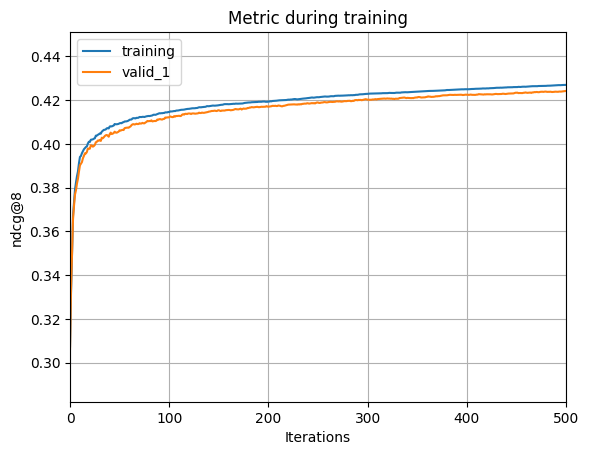

In [15]:
#plot stuff
lightgbm.plot_metric(ranker)

In [16]:
# validation set
preds = ranker.predict(X_val)
print(preds)

[-0.91819456 -0.45894028 -1.0586694  ... -0.68503015  0.01892695
 -0.38866584]


Run model on the test_data:

In [17]:
# load test set
test_path = "data/test_set_VU_DM.csv"
chunk = pd.read_csv(test_path, chunksize=1000000)
test_df = pd.concat(chunk)

# copied from data_prep.ipynb
test_df = test_df.drop(['date_time','orig_destination_distance','comp1_rate','comp1_inv','comp1_rate_percent_diff','comp2_rate','comp2_inv','comp2_rate_percent_diff','comp3_rate','comp3_inv','comp3_rate_percent_diff','comp4_rate','comp4_inv','comp4_rate_percent_diff','comp5_rate','comp5_inv','comp5_rate_percent_diff','comp6_rate','comp6_inv','comp6_rate_percent_diff','comp7_rate','comp7_inv','comp7_rate_percent_diff','comp8_rate','comp8_inv','comp8_rate_percent_diff','srch_query_affinity_score', 'visitor_hist_starrating','visitor_hist_adr_usd'],axis=1)

In [18]:
test_preds = ranker.predict(test_df)
print(test_preds)

[ 0.11779983  0.09135576  0.02910766 ... -0.87590519  0.18114751
  0.24273302]


In [19]:
# add predictions as column
test_df['prediction'] = test_preds

grouped = test_df.groupby('srch_id').apply(lambda x: x.sort_values('prediction', ascending=False))

# Reset the index to flatten the DataFrame
grouped = grouped.reset_index(drop=True)

# Select the top 5 for each search_id
top5 = grouped.groupby('srch_id')

print(top5)

In [20]:
grouped[['srch_id', 'prop_id']].to_csv('kaggle_predictions/lambdamart_predictions.csv', index=False, sep=',')